In [5]:
import numpy as np
import matplotlib.pyplot as plt

def _to_scalar(x):
    # 튜플/리스트/배열이면 첫 번째 원소만 사용 (원하는 규칙으로 바꾸면 됨)
    if isinstance(x, (tuple, list, np.ndarray)):
        if len(x) == 0:
            return np.nan
        return float(x[0])
    # pandas NA 등도 처리
    try:
        return float(x)
    except Exception:
        return np.nan

def plot_heatmap_like(df, vmin=None, vmax=None, cmap_name="YlGnBu",
                      fmt="{:.2f}", xlabel=r"$T_{\max}$", ylabel=r"$T_{\min}$",
                      nan_color="lightgray"):

    # df 값이 튜플일 수 있으니 스칼라로 변환
    data_raw = df.to_numpy()
    data = np.vectorize(_to_scalar, otypes=[float])(data_raw)

    mask = np.isnan(data)
    mdata = np.ma.array(data, mask=mask)

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color=nan_color)  # NaN 칸 색

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(mdata, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap, origin="upper")

    # tick label도 튜플이면 첫 원소만 보이게
    xlabels = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    ylabels = [i[0] if isinstance(i, tuple) else i for i in df.index]

    ax.set_xticks(np.arange(df.shape[1]), labels=xlabels,fontsize=16)
    ax.set_yticks(np.arange(df.shape[0]), labels=ylabels,fontsize=16)

    ax.set_xlabel(xlabel,fontsize=18)  # 수식 렌더링
    ax.set_ylabel(ylabel,fontsize=18)

    # (원하면) 셀 경계선
    ax.set_xticks(np.arange(-.5, df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, df.shape[0], 1), minor=True)
    ax.tick_params(which="minor", bottom=False, left=False)

    # 값 주석
    for (i, j), val in np.ndenumerate(data):
        if np.isnan(val):
            continue
        txt_color = "white" if im.norm(val) > 0.6 else "black"
        ax.text(j, i, fmt.format(val), ha="center", va="center",
                color=txt_color, fontsize=12)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    return fig, ax


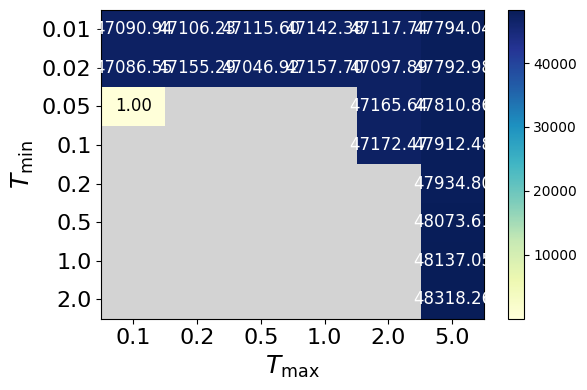

In [6]:
import pickle
import pandas as pd
name = 'ilp'
graph_type = 'ca'
max_num_nodes = 2000
formulations = ['max_linear_square']
proposal_types = ['obj']
init_temps = [1]
path_lengths = [1]
penalty_weight = 1000000
t_schedule = 'pt'
t_min_list = [0.01,0.02,0.05,0.1,0.2,0.5,1.0,2.0]
t_max_list = [0.1,0.2,0.5,1.0,2.0,5.0]
reweights = ['mask']
batch_size = 20

df = pd.DataFrame(columns = [t_max_list],index=[t_min_list])
for formulation in formulations:
    for init_temp in init_temps:
        for path_length in path_lengths:
            for reweight in reweights:
                for proposal_type in proposal_types:
                    for t_min in t_min_list:
                        for t_max in t_max_list:
                            if t_min >= t_max:
                                continue
                            path = f'./discs/results/{name}/results_{name}_{graph_type}_{max_num_nodes}_{formulation}_{proposal_type}_{init_temp}_{path_length}_{penalty_weight}_{t_schedule}_deo_1000_{t_min}_{t_max}_{reweight}_{batch_size}.pkl'
                            try:
                                with open(path, 'rb') as f:
                                    data1 = pickle.load(f)
                            except:
                                continue
                            df.loc[t_min,t_max] = data1['best_ratio_mean']
                            if len(data1['best_ratio']) <20:
                                df.loc[t_min,t_max] =  len(data1['best_ratio'])
df          

# 사용 예시: vmin/vmax도 튜플 값 대응하려면 함수 안에서 계산하거나,
# 아래처럼 안전하게 전체 스칼라 data 기반으로 주는 게 좋음.
fig, ax = plot_heatmap_like(df, vmin=None, vmax=None)
plt.show()
# save as pdf
fig.savefig(f'{graph_type}_{max_num_nodes}_{batch_size}_heatmap.pdf')

In [7]:
df

,0.1,0.2,0.5,1.0,2.0,5.0
0.01,47090.941406,47106.226562,47115.601562,47142.382812,47117.742188,47794.042969
0.02,47086.546875,47155.292969,47046.921875,47157.699219,47097.886719,47792.984375
0.05,1,NaN,NaN,NaN,47165.640625,47810.863281
0.10,NaN,NaN,NaN,NaN,47172.472656,47912.480469
0.20,NaN,NaN,NaN,NaN,NaN,47934.804688
0.50,NaN,NaN,NaN,NaN,NaN,48073.613281
1.00,NaN,NaN,NaN,NaN,NaN,48137.054688
2.00,NaN,NaN,NaN,NaN,NaN,48318.257812


In [14]:
df.max().max()

np.float32(47810.863)

# 2

In [4]:
import pickle
import pandas as pd
name = 'ilp'
graph_type = 'ca'
max_num_nodes = 2000
formulations = ['max_linear_square']
proposal_types = ['obj']
init_temps = [5]
path_lengths = [1]
penalty_weight = 1000
t_schedule = 'exp_decay'
sampler_name='path_auxiliary'
t_min_list = [0.1]
t_max_list = [5.0]
reweights = ['None']
batch_size = 20

for formulation in formulations:
    for init_temp in init_temps:
        for path_length in path_lengths:
            for reweight in reweights:
                for proposal_type in proposal_types:
                
                    path = f'./discs/results/{name}/results_{name}_{graph_type}_{max_num_nodes}_{formulation}_{proposal_type}_{init_temp}_{path_length}_{penalty_weight}_{t_schedule}_deo_1000_0.1_5.0_{reweight}_{batch_size}.pkl'
                    # print(path)
                    with open(path, 'rb') as f:
                        data1 = pickle.load(f)
                    if len(data1['best_ratio']) <20:
                        print(len(data1['best_ratio']))
                    else:
                        print(f'graph_type: {graph_type}, formulation: {formulation}, proposal_type:, init_temp: {init_temp}, reweight: {reweight}, best_ratio_mean: {data1["best_ratio_mean"]}')

graph_type: ca, formulation: max_linear_square, proposal_type:, init_temp: 5, reweight: None, best_ratio_mean: 51911.6328125


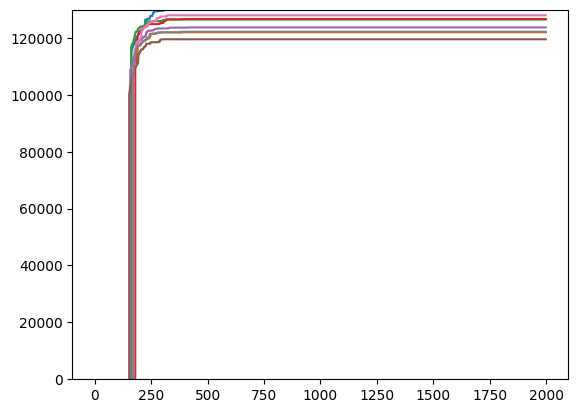

In [29]:
import matplotlib.pyplot as plt
for i in range(len(data1['best_ratio'])):
    plt.plot(data1['trajectory'][:,i])
    plt.ylim(-100,130000)